# Notebook 1: Local Model Training — 30-Day Hospital Readmission Prediction

**Objective:** Train a machine learning model locally using synthetic healthcare data to predict whether a patient will be readmitted to the hospital within 30 days of discharge.

**Steps:**
1. Generate synthetic patient, admission, and clinical data
2. Engineer features relevant to readmission risk
3. Train a GradientBoostingClassifier
4. Evaluate the model (AUC, precision, recall)
5. Save the trained model and data artifacts for upload to Snowflake

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import os

np.random.seed(42)
random.seed(42)

PROJECT_DIR = os.path.dirname(os.path.abspath('__file__'))
ARTIFACTS_DIR = os.path.join(PROJECT_DIR, 'artifacts')
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")
print(f"Artifacts directory: {ARTIFACTS_DIR}")

Project directory: /Users/moahmed/Desktop/Dev/healthcare-readmission-ml
Artifacts directory: /Users/moahmed/Desktop/Dev/healthcare-readmission-ml/artifacts


## 1. Generate Synthetic Healthcare Data

We create three tables that mirror what a hospital EHR system would contain:
- **PATIENTS** — Demographics (age, gender, insurance type)
- **ADMISSIONS** — Hospital visits (dates, diagnosis, procedures, discharge disposition)
- **CLINICAL_MEASUREMENTS** — Vitals and lab values at discharge

In [2]:
# --- PATIENTS TABLE ---
NUM_PATIENTS = 5000

patients = pd.DataFrame({
    'PATIENT_ID': [f'P{str(i).zfill(5)}' for i in range(1, NUM_PATIENTS + 1)],
    'AGE': np.random.normal(65, 15, NUM_PATIENTS).clip(18, 100).astype(int),
    'GENDER': np.random.choice(['M', 'F'], NUM_PATIENTS, p=[0.48, 0.52]),
    'INSURANCE_TYPE': np.random.choice(
        ['MEDICARE', 'MEDICAID', 'PRIVATE', 'SELF_PAY'], 
        NUM_PATIENTS, p=[0.45, 0.20, 0.30, 0.05]
    ),
    'ZIP_CODE': np.random.choice(
        ['10001', '10002', '10003', '10004', '10005', '20001', '20002', '30001', '30002', '40001'],
        NUM_PATIENTS
    ),
    'HAS_PCP': np.random.choice([True, False], NUM_PATIENTS, p=[0.70, 0.30])
})

print(f"Patients table: {patients.shape}")
patients.head()

Patients table: (5000, 6)


,PATIENT_ID,AGE,GENDER,INSURANCE_TYPE,ZIP_CODE,HAS_PCP
0,P00001,72,M,MEDICARE,10002,True
1,P00002,62,M,MEDICARE,10005,True
2,P00003,74,M,PRIVATE,30001,True
3,P00004,87,M,MEDICARE,30001,True
4,P00005,61,M,MEDICARE,20001,True


In [3]:
# --- ADMISSIONS TABLE ---
# Each patient has 1-5 admissions over the past 2 years
admission_records = []
admission_id = 1

DIAGNOSES = [
    'HEART_FAILURE', 'PNEUMONIA', 'COPD', 'DIABETES_COMPLICATIONS',
    'ACUTE_MI', 'SEPSIS', 'HIP_FRACTURE', 'STROKE', 'RENAL_FAILURE', 'GI_BLEED'
]
DISCHARGE_DISPOSITIONS = ['HOME', 'SNF', 'HOME_HEALTH', 'REHAB', 'AMA']

base_date = datetime(2025, 1, 1)

for _, patient in patients.iterrows():
    num_admissions = np.random.choice([1, 2, 3, 4, 5], p=[0.40, 0.25, 0.20, 0.10, 0.05])
    
    for j in range(num_admissions):
        admit_date = base_date - timedelta(days=random.randint(1, 730))
        los = max(1, int(np.random.exponential(5)))
        discharge_date = admit_date + timedelta(days=los)
        
        # Higher readmission probability for certain conditions and demographics
        diagnosis = np.random.choice(DIAGNOSES)
        readmit_prob = 0.15  # base rate
        if diagnosis in ['HEART_FAILURE', 'COPD', 'SEPSIS']:
            readmit_prob += 0.10
        if patient['AGE'] > 75:
            readmit_prob += 0.08
        if not patient['HAS_PCP']:
            readmit_prob += 0.05
        if patient['INSURANCE_TYPE'] == 'MEDICAID':
            readmit_prob += 0.05
        if los <= 2:
            readmit_prob += 0.07
            
        readmitted_30d = int(np.random.random() < readmit_prob)
        
        admission_records.append({
            'ADMISSION_ID': f'A{str(admission_id).zfill(6)}',
            'PATIENT_ID': patient['PATIENT_ID'],
            'ADMIT_DATE': admit_date.strftime('%Y-%m-%d'),
            'DISCHARGE_DATE': discharge_date.strftime('%Y-%m-%d'),
            'LENGTH_OF_STAY': los,
            'PRIMARY_DIAGNOSIS': diagnosis,
            'NUM_PROCEDURES': np.random.poisson(2),
            'NUM_DIAGNOSES': np.random.poisson(4) + 1,
            'DISCHARGE_DISPOSITION': np.random.choice(
                DISCHARGE_DISPOSITIONS, p=[0.45, 0.20, 0.15, 0.15, 0.05]
            ),
            'ED_ADMISSION': int(np.random.random() < 0.35),
            'READMITTED_30D': readmitted_30d
        })
        admission_id += 1

admissions = pd.DataFrame(admission_records)
print(f"Admissions table: {admissions.shape}")
print(f"Readmission rate: {admissions['READMITTED_30D'].mean():.1%}")
admissions.head()

Admissions table: (10772, 11)
Readmission rate: 25.4%


,ADMISSION_ID,PATIENT_ID,ADMIT_DATE,DISCHARGE_DATE,LENGTH_OF_STAY,PRIMARY_DIAGNOSIS,NUM_PROCEDURES,NUM_DIAGNOSES,DISCHARGE_DISPOSITION,ED_ADMISSION,READMITTED_30D
0,A000001,P00001,2023-03-18,2023-03-27,9,SEPSIS,3,5,AMA,0,0
1,A000002,P00002,2024-09-08,2024-09-13,5,SEPSIS,4,5,HOME,1,0
2,A000003,P00003,2024-12-06,2024-12-08,2,RENAL_FAILURE,1,7,REHAB,1,0
3,A000004,P00004,2024-03-25,2024-03-26,1,COPD,2,8,HOME,1,0
4,A000005,P00005,2024-04-25,2024-05-08,13,DIABETES_COMPLICATIONS,2,7,REHAB,0,0


In [4]:
# --- CLINICAL MEASUREMENTS TABLE ---
# Vitals and lab values recorded at discharge for each admission
# Generate all values as arrays for performance and NumPy compatibility
n_admissions = len(admissions)

clinical = pd.DataFrame({
    'ADMISSION_ID': admissions['ADMISSION_ID'].values,
    'PATIENT_ID': admissions['PATIENT_ID'].values,
    'MEASUREMENT_DATE': admissions['DISCHARGE_DATE'].values,
    'HEART_RATE': np.clip(np.random.normal(80, 15, n_admissions), 50, 140).round(0),
    'SYSTOLIC_BP': np.clip(np.random.normal(130, 20, n_admissions), 80, 200).round(0),
    'DIASTOLIC_BP': np.clip(np.random.normal(75, 12, n_admissions), 50, 120).round(0),
    'TEMPERATURE': np.clip(np.random.normal(98.6, 0.8, n_admissions), 96, 104).round(1),
    'RESPIRATORY_RATE': np.clip(np.random.normal(18, 4, n_admissions), 10, 35).round(0),
    'O2_SATURATION': np.clip(np.random.normal(96, 3, n_admissions), 85, 100).round(1),
    'BLOOD_GLUCOSE': np.clip(np.random.normal(120, 40, n_admissions), 60, 400).round(0),
    'CREATININE': np.clip(np.random.lognormal(0.1, 0.4, n_admissions), 0.4, 8.0).round(2),
    'HEMOGLOBIN': np.clip(np.random.normal(12.5, 2, n_admissions), 6, 18).round(1),
    'WBC_COUNT': np.clip(np.random.lognormal(2.0, 0.4, n_admissions), 2, 30).round(1),
    'SODIUM': np.clip(np.random.normal(140, 4, n_admissions), 125, 155).round(0),
    'POTASSIUM': np.clip(np.random.normal(4.2, 0.5, n_admissions), 2.5, 6.5).round(1),
})

# BNP depends on patient age — merge to get age, compute conditionally
patient_ages = admissions.merge(patients[['PATIENT_ID', 'AGE']], on='PATIENT_ID', how='left')['AGE'].values
bnp_high = np.clip(np.random.lognormal(5.0, 1.2, n_admissions), 10, 5000).round(0)
bnp_low = np.clip(np.random.lognormal(3.5, 0.8, n_admissions), 10, 1000).round(0)
clinical['BNP'] = np.where(patient_ages > 60, bnp_high, bnp_low)

print(f"Clinical measurements table: {clinical.shape}")
clinical.head()

Clinical measurements table: (10772, 16)


,ADMISSION_ID,PATIENT_ID,MEASUREMENT_DATE,HEART_RATE,SYSTOLIC_BP,DIASTOLIC_BP,TEMPERATURE,RESPIRATORY_RATE,O2_SATURATION,BLOOD_GLUCOSE,CREATININE,HEMOGLOBIN,WBC_COUNT,SODIUM,POTASSIUM,BNP
0,A000001,P00001,2023-03-27,91.0,114.0,85.0,99.2,15.0,95.8,92.0,1.43,14.4,5.4,138.0,4.6,99.0
1,A000002,P00002,2024-09-13,79.0,141.0,83.0,97.5,18.0,95.0,161.0,1.28,9.7,3.6,137.0,4.6,4910.0
2,A000003,P00003,2024-12-08,63.0,149.0,77.0,98.7,17.0,95.7,60.0,1.71,11.1,4.5,132.0,3.9,58.0
3,A000004,P00004,2024-03-26,57.0,138.0,85.0,99.6,16.0,91.7,74.0,1.16,12.1,8.0,140.0,4.3,124.0
4,A000005,P00005,2024-05-08,83.0,119.0,85.0,98.4,20.0,96.3,60.0,1.24,13.8,8.8,143.0,5.3,128.0


## 2. Feature Engineering

We build features that clinical literature associates with readmission risk:
- **Patient-level:** Age, gender, insurance type, PCP status
- **Admission-level:** Length of stay, diagnosis risk, ED admission, discharge disposition
- **Clinical:** Abnormal vitals/labs at discharge
- **Historical:** Number of prior admissions in last 6 months, prior readmissions

In [5]:
# Merge all data at the admission level
df = admissions.merge(patients, on='PATIENT_ID', how='left')
df = df.merge(clinical, on=['ADMISSION_ID', 'PATIENT_ID'], how='left')

# Convert dates
df['ADMIT_DATE'] = pd.to_datetime(df['ADMIT_DATE'])
df['DISCHARGE_DATE'] = pd.to_datetime(df['DISCHARGE_DATE'])

# --- Historical features (per patient, per admission) ---
df = df.sort_values(['PATIENT_ID', 'ADMIT_DATE'])

def compute_historical_features(group):
    group = group.copy()
    prior_admissions_6m = []
    prior_readmissions = []
    avg_prior_los = []
    
    for idx, row in group.iterrows():
        prior = group[(group['ADMIT_DATE'] < row['ADMIT_DATE'])]
        prior_6m = prior[(row['ADMIT_DATE'] - prior['ADMIT_DATE']).dt.days <= 180]
        
        prior_admissions_6m.append(len(prior_6m))
        prior_readmissions.append(prior['READMITTED_30D'].sum() if len(prior) > 0 else 0)
        avg_prior_los.append(prior['LENGTH_OF_STAY'].mean() if len(prior) > 0 else 0)
    
    group['PRIOR_ADMISSIONS_6M'] = prior_admissions_6m
    group['PRIOR_READMISSIONS'] = prior_readmissions
    group['AVG_PRIOR_LOS'] = avg_prior_los
    return group

df = df.groupby('PATIENT_ID', group_keys=False).apply(compute_historical_features)

print(f"Merged dataset: {df.shape}")
df.head()

Merged dataset: (10772, 33)


/var/folders/_h/2ccckzrd43vc3n6cqgzydmf80000gn/T/ipykernel_67776/3195473994.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('PATIENT_ID', group_keys=False).apply(compute_historical_features)


,ADMISSION_ID,PATIENT_ID,ADMIT_DATE,DISCHARGE_DATE,LENGTH_OF_STAY,PRIMARY_DIAGNOSIS,NUM_PROCEDURES,NUM_DIAGNOSES,DISCHARGE_DISPOSITION,ED_ADMISSION,...,BLOOD_GLUCOSE,CREATININE,HEMOGLOBIN,WBC_COUNT,SODIUM,POTASSIUM,BNP,PRIOR_ADMISSIONS_6M,PRIOR_READMISSIONS,AVG_PRIOR_LOS
0,A000001,P00001,2023-03-18,2023-03-27,9,SEPSIS,3,5,AMA,0,...,92.0,1.43,14.4,5.4,138.0,4.6,99.0,0,0,0.0
1,A000002,P00002,2024-09-08,2024-09-13,5,SEPSIS,4,5,HOME,1,...,161.0,1.28,9.7,3.6,137.0,4.6,4910.0,0,0,0.0
2,A000003,P00003,2024-12-06,2024-12-08,2,RENAL_FAILURE,1,7,REHAB,1,...,60.0,1.71,11.1,4.5,132.0,3.9,58.0,0,0,0.0
3,A000004,P00004,2024-03-25,2024-03-26,1,COPD,2,8,HOME,1,...,74.0,1.16,12.1,8.0,140.0,4.3,124.0,0,0,0.0
4,A000005,P00005,2024-04-25,2024-05-08,13,DIABETES_COMPLICATIONS,2,7,REHAB,0,...,60.0,1.24,13.8,8.8,143.0,5.3,128.0,0,0,0.0


In [6]:
# --- Encode categorical variables ---
from sklearn.preprocessing import LabelEncoder

# Diagnosis risk score (high-risk diagnoses get higher score)
DIAGNOSIS_RISK = {
    'HEART_FAILURE': 3, 'SEPSIS': 3, 'COPD': 2, 'RENAL_FAILURE': 2,
    'ACUTE_MI': 2, 'DIABETES_COMPLICATIONS': 2, 'STROKE': 2,
    'PNEUMONIA': 1, 'GI_BLEED': 1, 'HIP_FRACTURE': 1
}
df['DIAGNOSIS_RISK_SCORE'] = df['PRIMARY_DIAGNOSIS'].map(DIAGNOSIS_RISK)

# Discharge disposition encoding (higher = higher risk of readmission)
DISPOSITION_RISK = {'HOME': 0, 'HOME_HEALTH': 1, 'REHAB': 1, 'SNF': 2, 'AMA': 3}
df['DISPOSITION_RISK_SCORE'] = df['DISCHARGE_DISPOSITION'].map(DISPOSITION_RISK)

# Gender encoding
df['GENDER_ENC'] = (df['GENDER'] == 'M').astype(int)

# Insurance encoding
le_insurance = LabelEncoder()
df['INSURANCE_ENC'] = le_insurance.fit_transform(df['INSURANCE_TYPE'])

# PCP flag
df['HAS_PCP_FLAG'] = df['HAS_PCP'].astype(int)

# Clinical abnormality flags
df['ABNORMAL_HR'] = ((df['HEART_RATE'] > 100) | (df['HEART_RATE'] < 60)).astype(int)
df['ABNORMAL_BP'] = ((df['SYSTOLIC_BP'] > 160) | (df['SYSTOLIC_BP'] < 90)).astype(int)
df['LOW_O2'] = (df['O2_SATURATION'] < 93).astype(int)
df['HIGH_CREATININE'] = (df['CREATININE'] > 1.5).astype(int)
df['LOW_HEMOGLOBIN'] = (df['HEMOGLOBIN'] < 10).astype(int)
df['HIGH_BNP'] = (df['BNP'] > 500).astype(int)
df['ABNORMAL_GLUCOSE'] = ((df['BLOOD_GLUCOSE'] > 200) | (df['BLOOD_GLUCOSE'] < 70)).astype(int)

print("Feature engineering complete.")
print(f"Total features available: {len(df.columns)}")

Feature engineering complete.
Total features available: 45


In [7]:
# --- Define feature set for model training ---
FEATURE_COLUMNS = [
    'AGE', 'GENDER_ENC', 'INSURANCE_ENC', 'HAS_PCP_FLAG',
    'LENGTH_OF_STAY', 'NUM_PROCEDURES', 'NUM_DIAGNOSES',
    'DIAGNOSIS_RISK_SCORE', 'DISPOSITION_RISK_SCORE', 'ED_ADMISSION',
    'HEART_RATE', 'SYSTOLIC_BP', 'DIASTOLIC_BP', 'TEMPERATURE',
    'RESPIRATORY_RATE', 'O2_SATURATION', 'BLOOD_GLUCOSE', 'CREATININE',
    'HEMOGLOBIN', 'WBC_COUNT', 'SODIUM', 'POTASSIUM', 'BNP',
    'ABNORMAL_HR', 'ABNORMAL_BP', 'LOW_O2', 'HIGH_CREATININE',
    'LOW_HEMOGLOBIN', 'HIGH_BNP', 'ABNORMAL_GLUCOSE',
    'PRIOR_ADMISSIONS_6M', 'PRIOR_READMISSIONS', 'AVG_PRIOR_LOS'
]

TARGET = 'READMITTED_30D'

X = df[FEATURE_COLUMNS].fillna(0)
y = df[TARGET]

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True).to_string()}")

Feature matrix shape: (10772, 33)
Target distribution:
READMITTED_30D
0    0.746008
1    0.253992


## 3. Train the Model

We use a GradientBoostingClassifier — a strong baseline for tabular binary classification that works well for healthcare readmission prediction.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Split data 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Train readmission rate: {y_train.mean():.1%}")
print(f"Test readmission rate: {y_test.mean():.1%}")

Training set: 8617 samples
Test set: 2155 samples
Train readmission rate: 25.4%
Test readmission rate: 25.4%


In [9]:
# Train GradientBoosting model
model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    min_samples_leaf=20,
    random_state=42
)

model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


## 4. Evaluate the Model

In [10]:
# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Metrics
auc_score = roc_auc_score(y_test, y_pred_proba)
ap_score = average_precision_score(y_test, y_pred_proba)

print(f"ROC AUC: {auc_score:.4f}")
print(f"Average Precision: {ap_score:.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted']))

ROC AUC: 0.5520
Average Precision: 0.2895

Classification Report:

                precision    recall  f1-score   support

Not Readmitted       0.75      0.97      0.84      1608
    Readmitted       0.31      0.04      0.07       547

      accuracy                           0.73      2155
     macro avg       0.53      0.50      0.46      2155
  weighted avg       0.64      0.73      0.65      2155



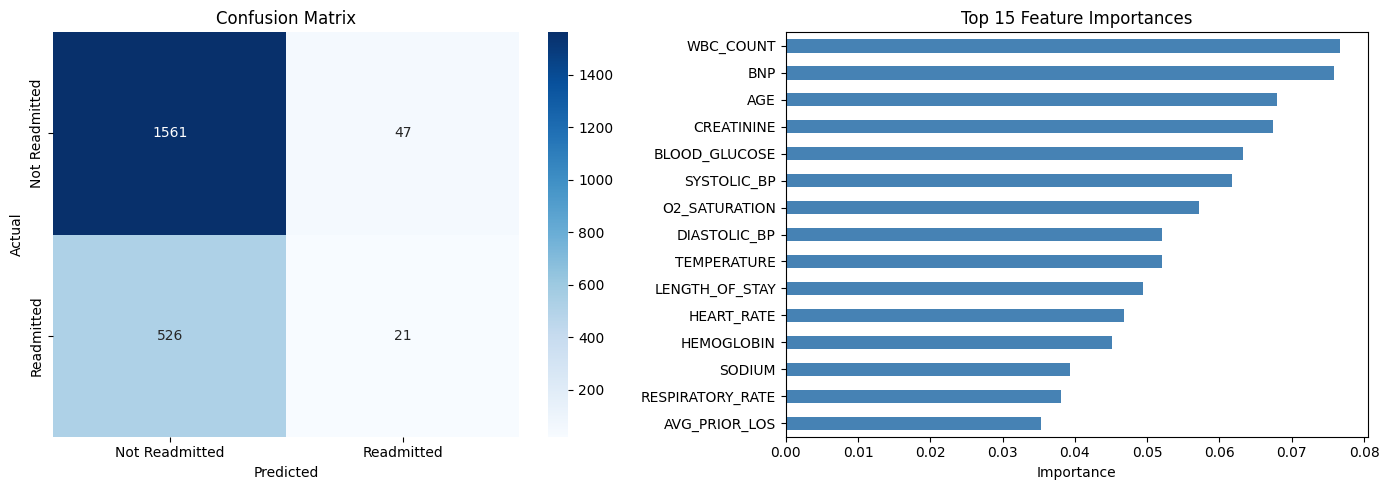

Evaluation plots saved.


In [11]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Feature importance (top 15)
feat_imp = pd.Series(model.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=True)
feat_imp.tail(15).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'model_evaluation.png'), dpi=150)
plt.show()
print("Evaluation plots saved.")

## 5. Save Artifacts for Snowflake Upload

Save the trained model and raw data CSVs that will be uploaded to Snowflake in the next notebook.

In [12]:
import joblib

# Save the trained model
model_path = os.path.join(ARTIFACTS_DIR, 'readmission_model.joblib')
joblib.dump(model, model_path)
print(f"Model saved to: {model_path}")

# Save raw data CSVs for Snowflake upload
patients.to_csv(os.path.join(ARTIFACTS_DIR, 'patients.csv'), index=False)
admissions.to_csv(os.path.join(ARTIFACTS_DIR, 'admissions.csv'), index=False)
clinical.to_csv(os.path.join(ARTIFACTS_DIR, 'clinical.csv'), index=False)

# Save the feature-engineered dataset (for training data reference in Snowflake)
train_data = X_train.copy()
train_data[TARGET] = y_train.values
train_data.to_csv(os.path.join(ARTIFACTS_DIR, 'training_data.csv'), index=False)

test_data = X_test.copy()
test_data[TARGET] = y_test.values
test_data.to_csv(os.path.join(ARTIFACTS_DIR, 'test_data.csv'), index=False)

# Save feature columns and label encoder for consistency
import json
metadata = {
    'feature_columns': FEATURE_COLUMNS,
    'target': TARGET,
    'insurance_classes': le_insurance.classes_.tolist(),
    'diagnosis_risk_map': DIAGNOSIS_RISK,
    'disposition_risk_map': DISPOSITION_RISK,
    'model_metrics': {
        'roc_auc': round(auc_score, 4),
        'average_precision': round(ap_score, 4)
    },
    'training_samples': int(X_train.shape[0]),
    'test_samples': int(X_test.shape[0])
}

with open(os.path.join(ARTIFACTS_DIR, 'model_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print("\nAll artifacts saved:")
for f in os.listdir(ARTIFACTS_DIR):
    size = os.path.getsize(os.path.join(ARTIFACTS_DIR, f))
    print(f"  {f}: {size:,} bytes")

Model saved to: /Users/moahmed/Desktop/Dev/healthcare-readmission-ml/artifacts/readmission_model.joblib

All artifacts saved:
  model_metadata.json: 1,298 bytes
  admissions.csv: 690,702 bytes
  training_data.csv: 967,928 bytes
  readmission_model.joblib: 414,680 bytes
  clinical.csv: 995,225 bytes
  model_evaluation.png: 83,458 bytes
  patients.csv: 160,146 bytes
  test_data.csv: 242,235 bytes


In [13]:
# Quick sanity check — reload model and verify predictions match
loaded_model = joblib.load(model_path)
loaded_preds = loaded_model.predict_proba(X_test)[:, 1]
assert np.allclose(y_pred_proba, loaded_preds), "Model serialization mismatch!"
print("Model serialization verified — predictions match after reload.")
print(f"\nReady for Snowflake upload. Proceed to Notebook 02.")

Model serialization verified — predictions match after reload.

Ready for Snowflake upload. Proceed to Notebook 02.
